In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv("train.csv", sep=";")
test = pd.read_csv("test.csv", sep=";")


In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (45211, 17)
Test shape: (4521, 17)


In [4]:
print(train.columns.tolist())
print(test.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [5]:
train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
train.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [9]:
for col in train.columns:
    print(f"\n{col}")
    print("Unique values:", train[col].nunique())
    print(train[col].unique()[:20])


age
Unique values: 77
[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39]

job
Unique values: 12
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital
Unique values: 3
['married' 'single' 'divorced']

education
Unique values: 4
['tertiary' 'secondary' 'unknown' 'primary']

default
Unique values: 2
['no' 'yes']

balance
Unique values: 7168
[2143   29    2 1506    1  231  447  121  593  270  390    6   71  162
  229   13   52   60    0  723]

housing
Unique values: 2
['yes' 'no']

loan
Unique values: 2
['no' 'yes']

contact
Unique values: 3
['unknown' 'cellular' 'telephone']

day
Unique values: 31
[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2]

month
Unique values: 12
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

duration
Unique values: 1573
[261 151  76  92 198 139 217 380  50  55 222 137 517  71 174 353  98  38
 219  54]

campai

In [10]:
train['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [11]:
train['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [12]:
train['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [13]:
train['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [14]:
train.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [15]:
train.duplicated().sum()

np.int64(0)

In [17]:
num_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

cat_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

In [18]:
target = 'y'

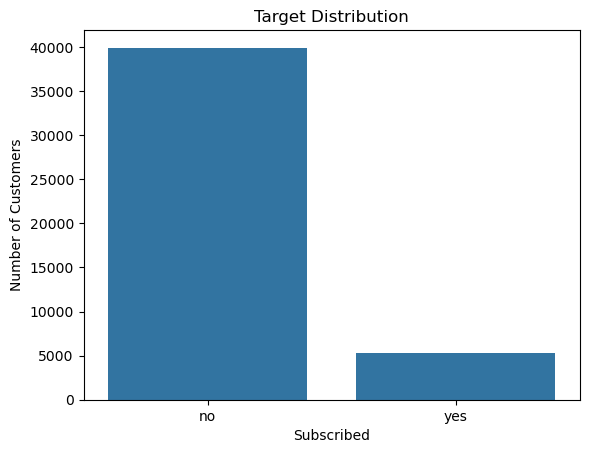

In [19]:
sns.countplot(data=train, x='y')

plt.title("Target Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")
plt.show()

In [20]:
train['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [21]:
train['y'].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

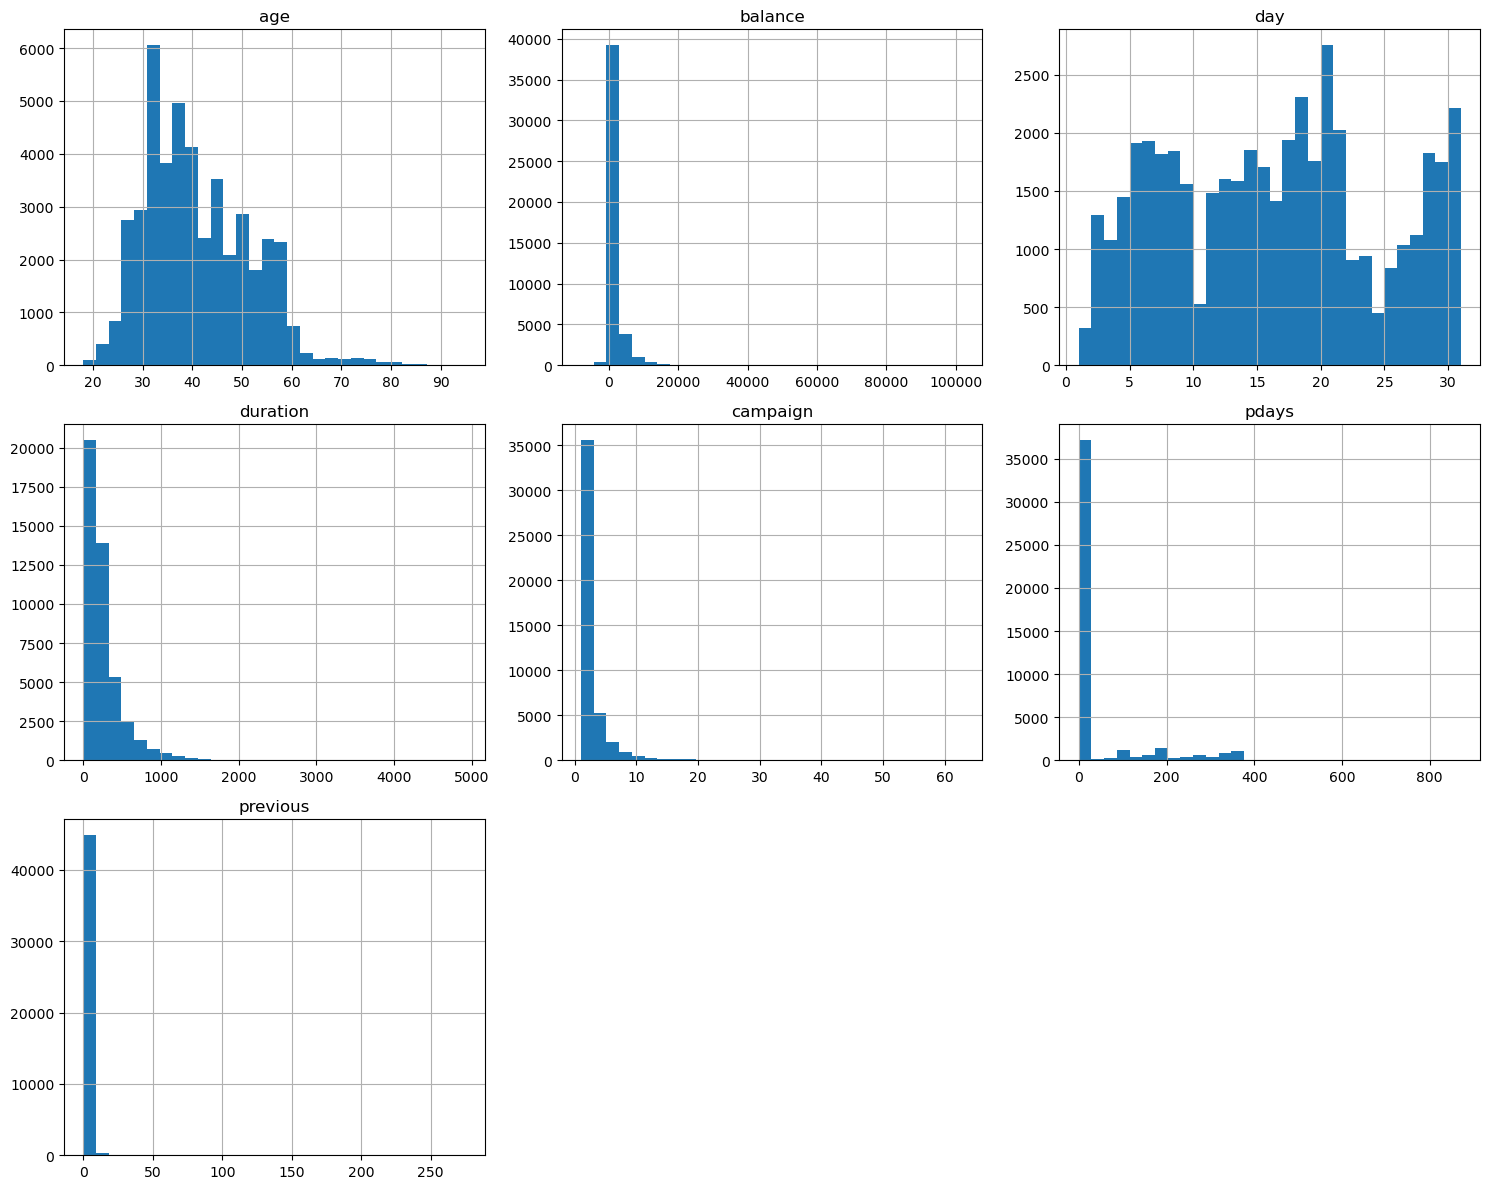

In [22]:
num_cols = train.select_dtypes(include=np.number).columns

train[num_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [23]:
train[num_cols].skew().sort_values(ascending=False)

previous    41.846454
balance      8.360308
campaign     4.898650
duration     3.144318
pdays        2.615715
age          0.684818
day          0.093079
dtype: float64

In [24]:
for col in cat_cols:
    rate = pd.crosstab(
        train[col],
        train['y'],
        normalize='index'
    )['yes'].sort_values(ascending=False)

    print(f"\n{col}")
    print(rate)


job
job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: yes, dtype: float64

marital
marital
single      0.149492
divorced    0.119455
married     0.101235
Name: yes, dtype: float64

education
education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: yes, dtype: float64

default
default
no     0.117961
yes    0.063804
Name: yes, dtype: float64

housing
housing
no     0.167024
yes    0.077000
Name: yes, dtype: float64

loan
loan
no     0.126557
yes    0.066814
Name: yes, dtype: float64

contact
contact
cellular     0.149189
telephone    0.134205
unknown      0.040707
Name: yes, dtype: float64

month
month
mar    0.519916
dec    0.467290
sep    0.464594
oct    0.437669
apr    

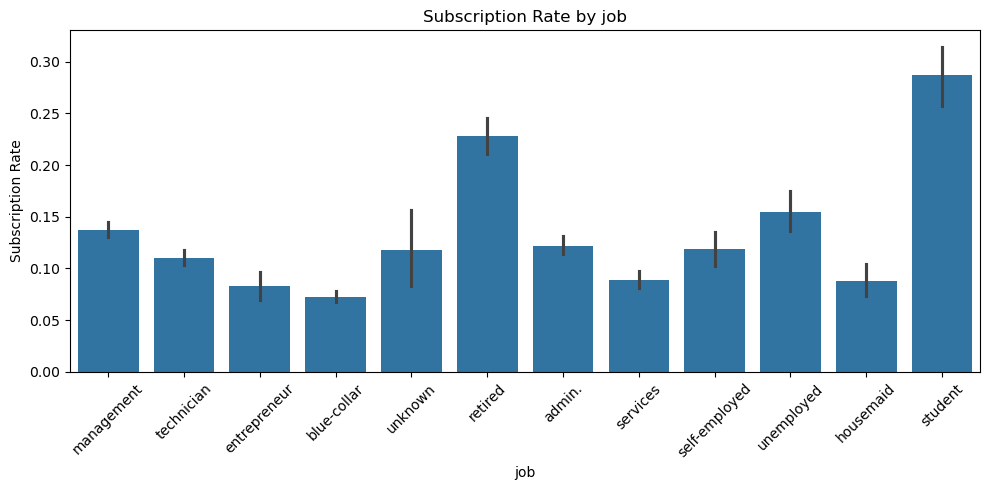

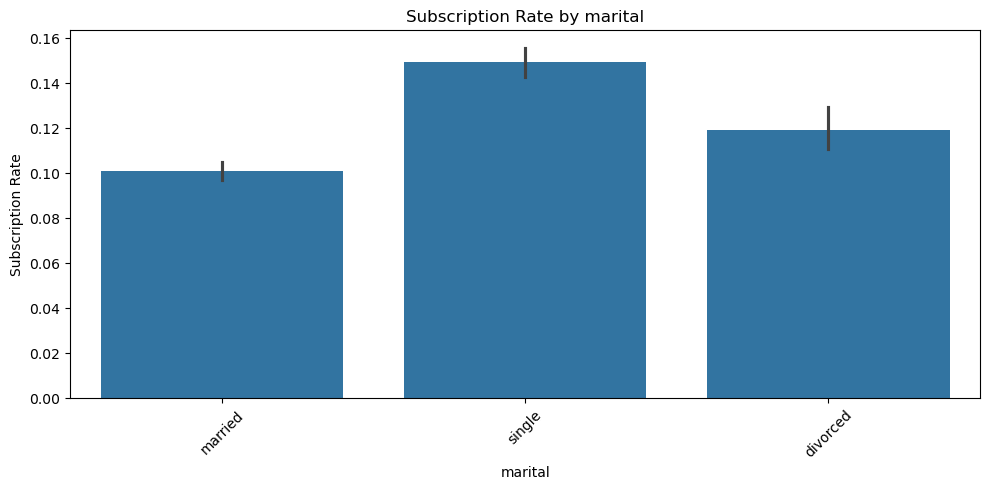

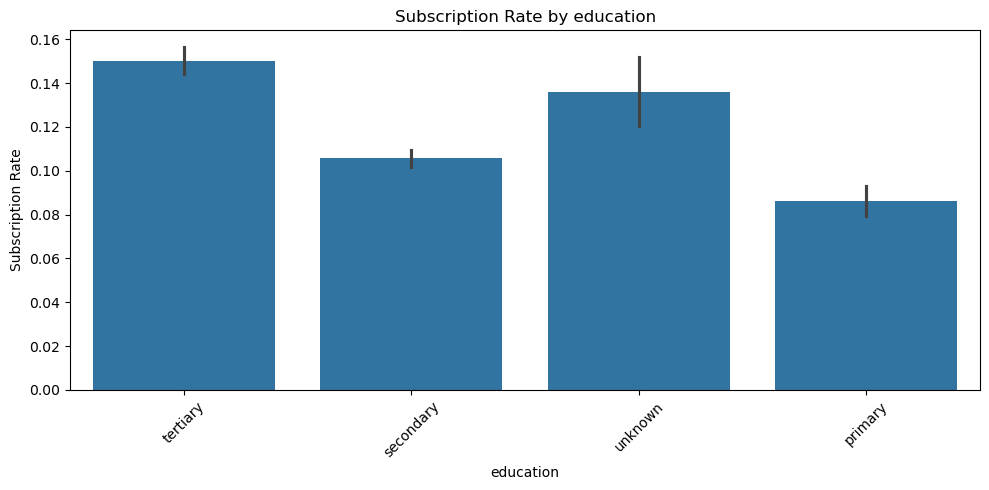

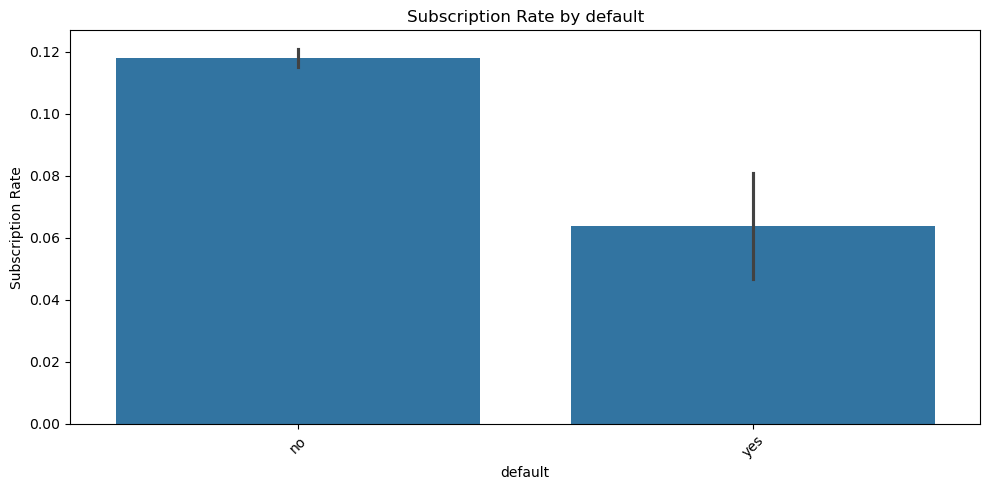

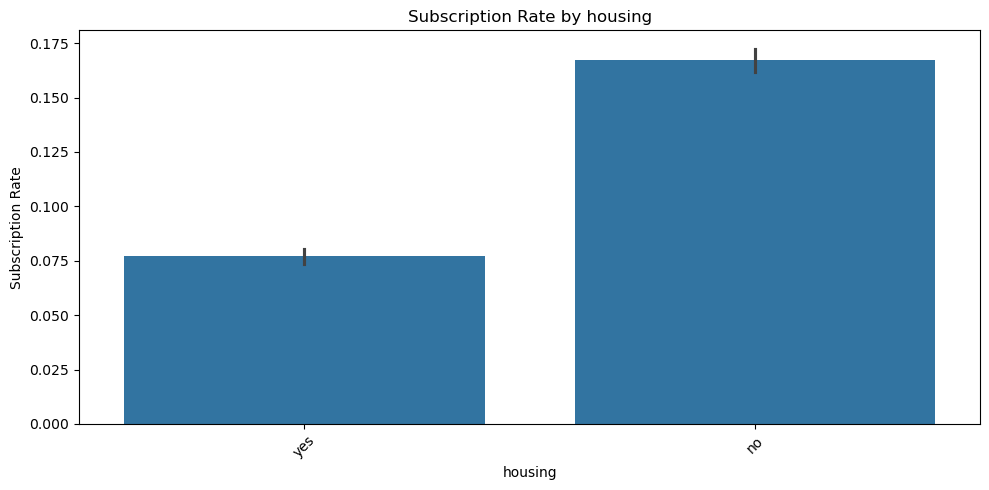

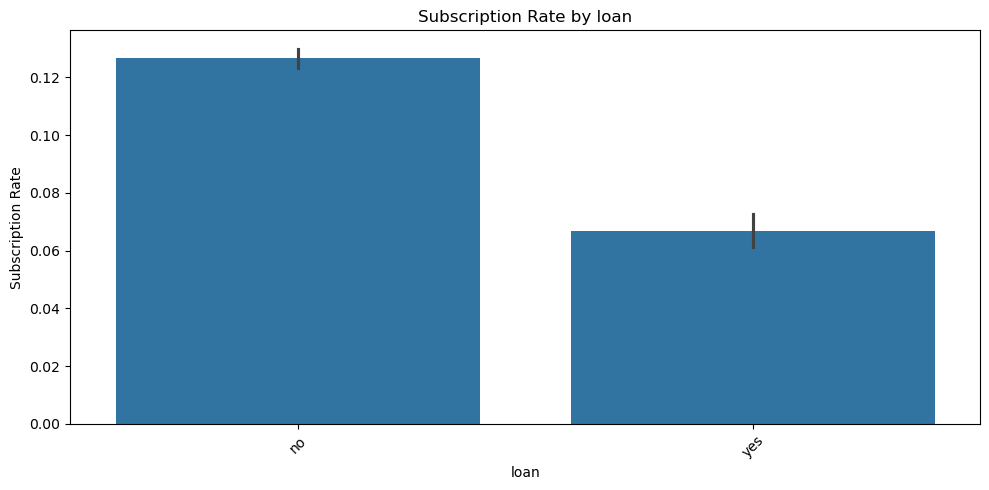

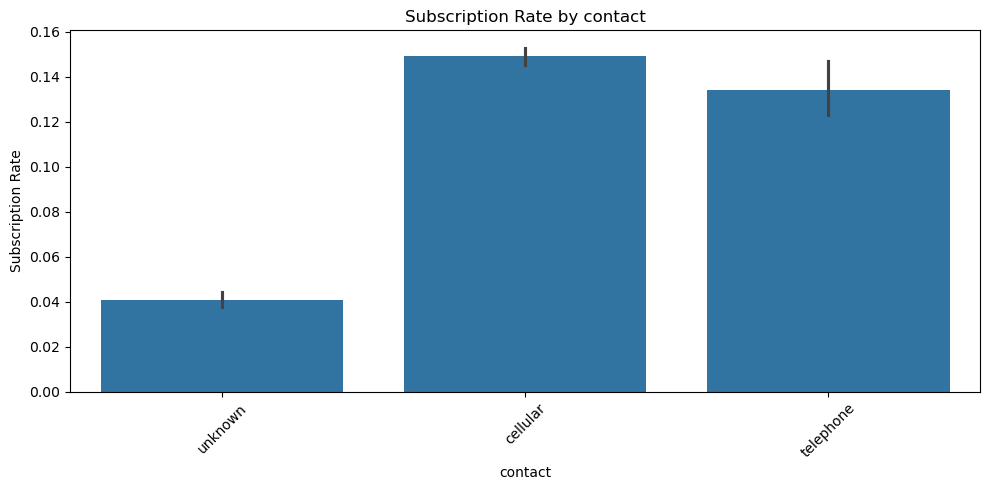

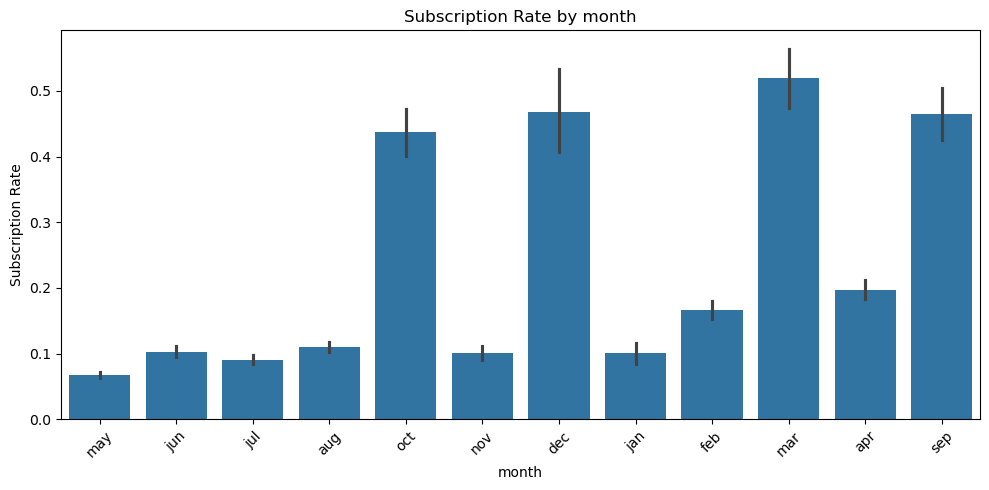

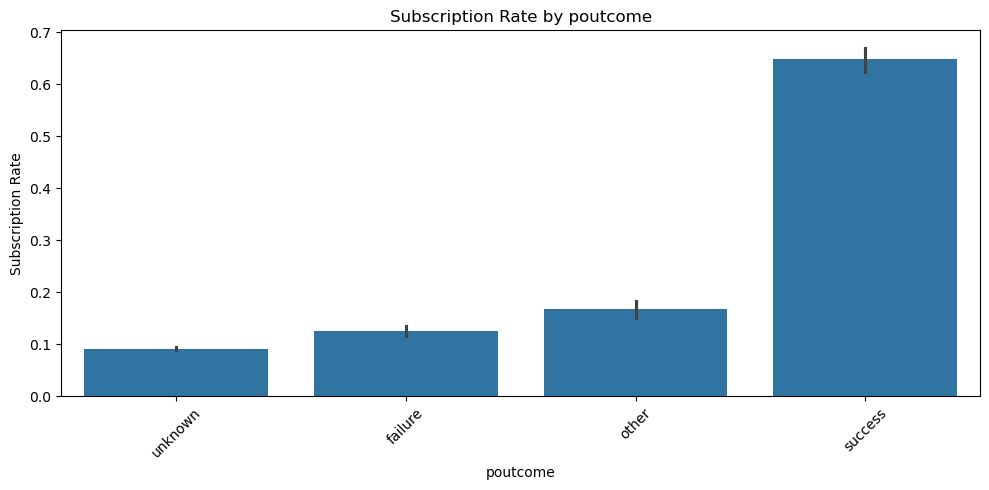

In [25]:
for col in cat_cols:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=train,
        x=col,
        y=train['y'].map({'no': 0, 'yes': 1})
    )

    plt.title(f"Subscription Rate by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Subscription Rate")
    plt.tight_layout()
    plt.show()

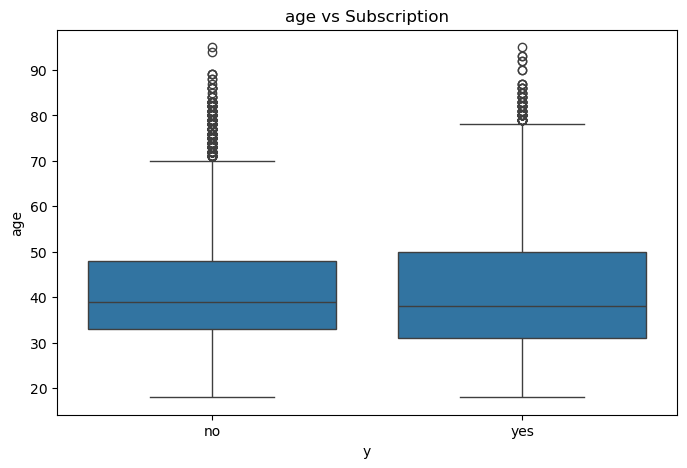

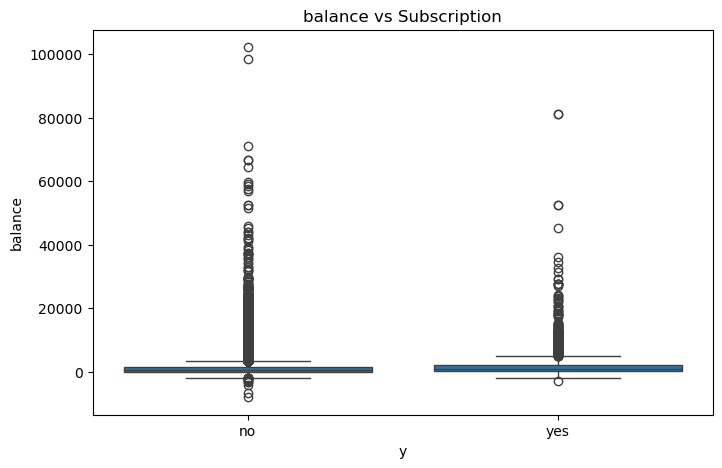

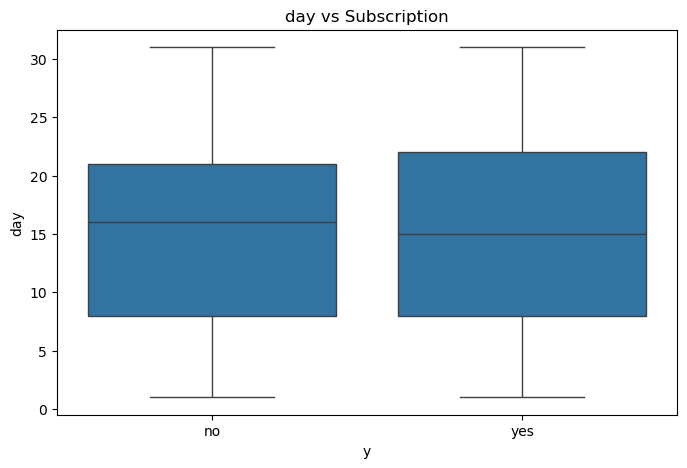

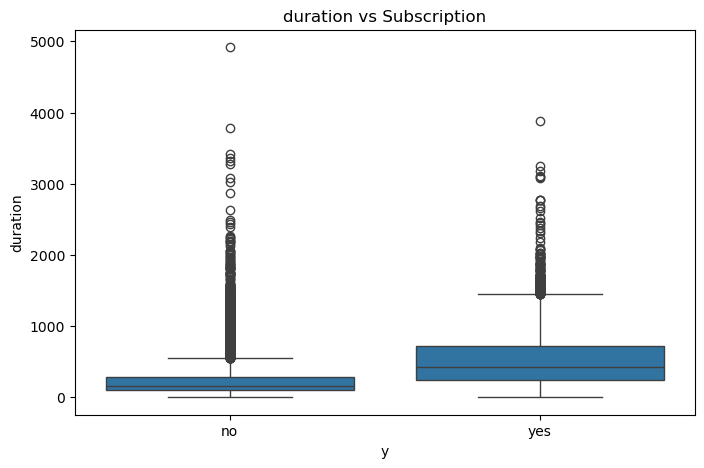

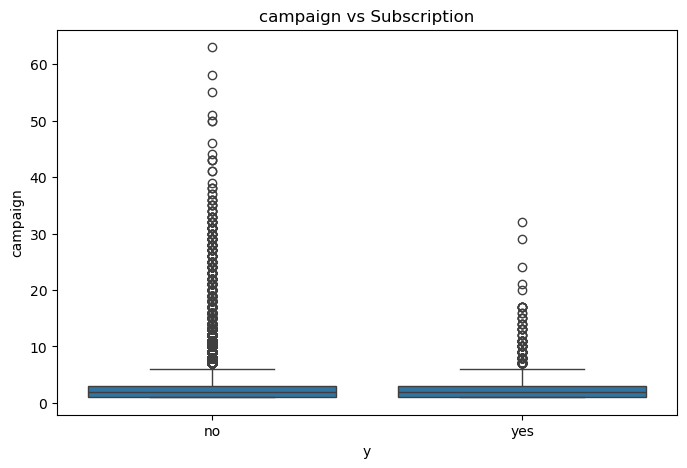

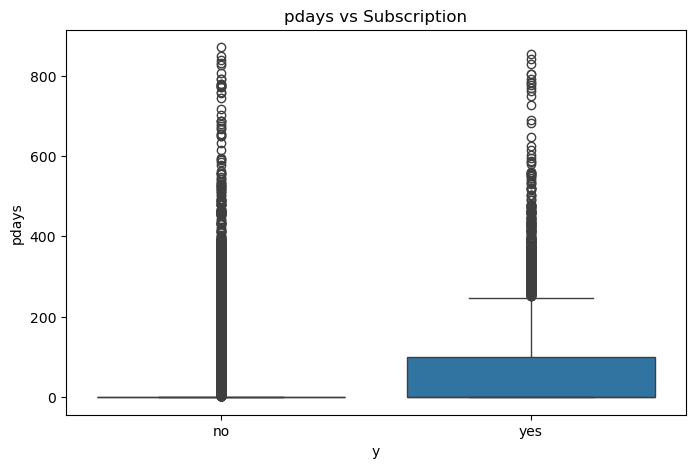

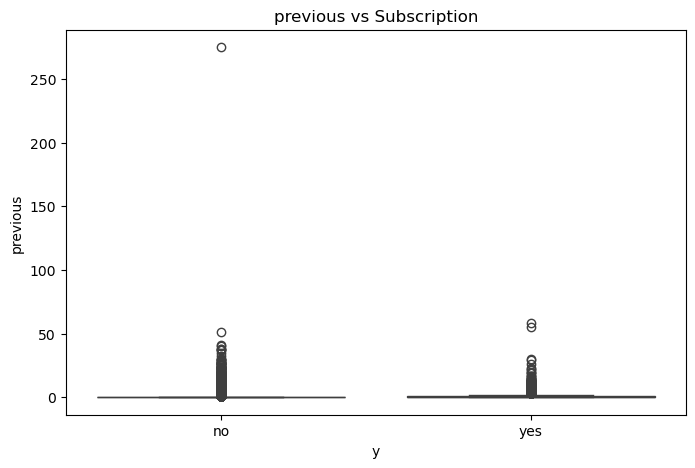

In [26]:
for col in num_cols:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=train,
        x='y',
        y=col
    )

    plt.title(f"{col} vs Subscription")
    plt.show()

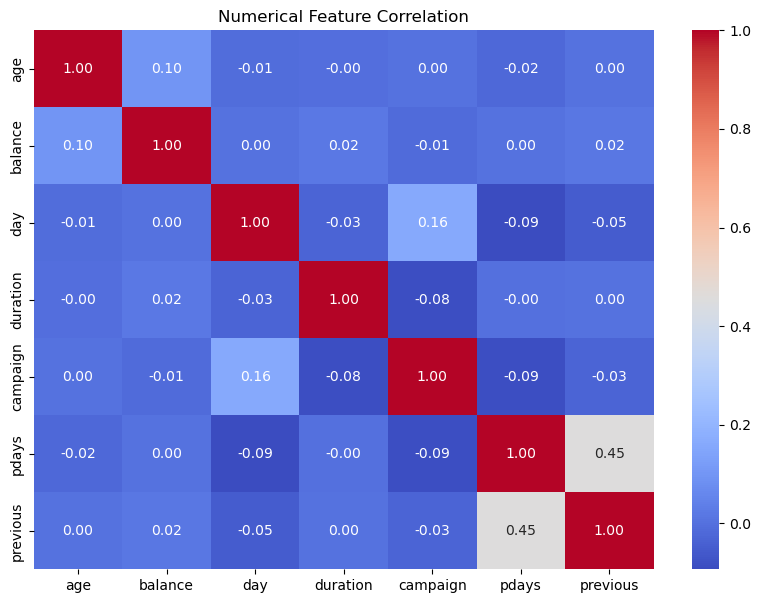

In [27]:
corr = train[num_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Numerical Feature Correlation")
plt.show()

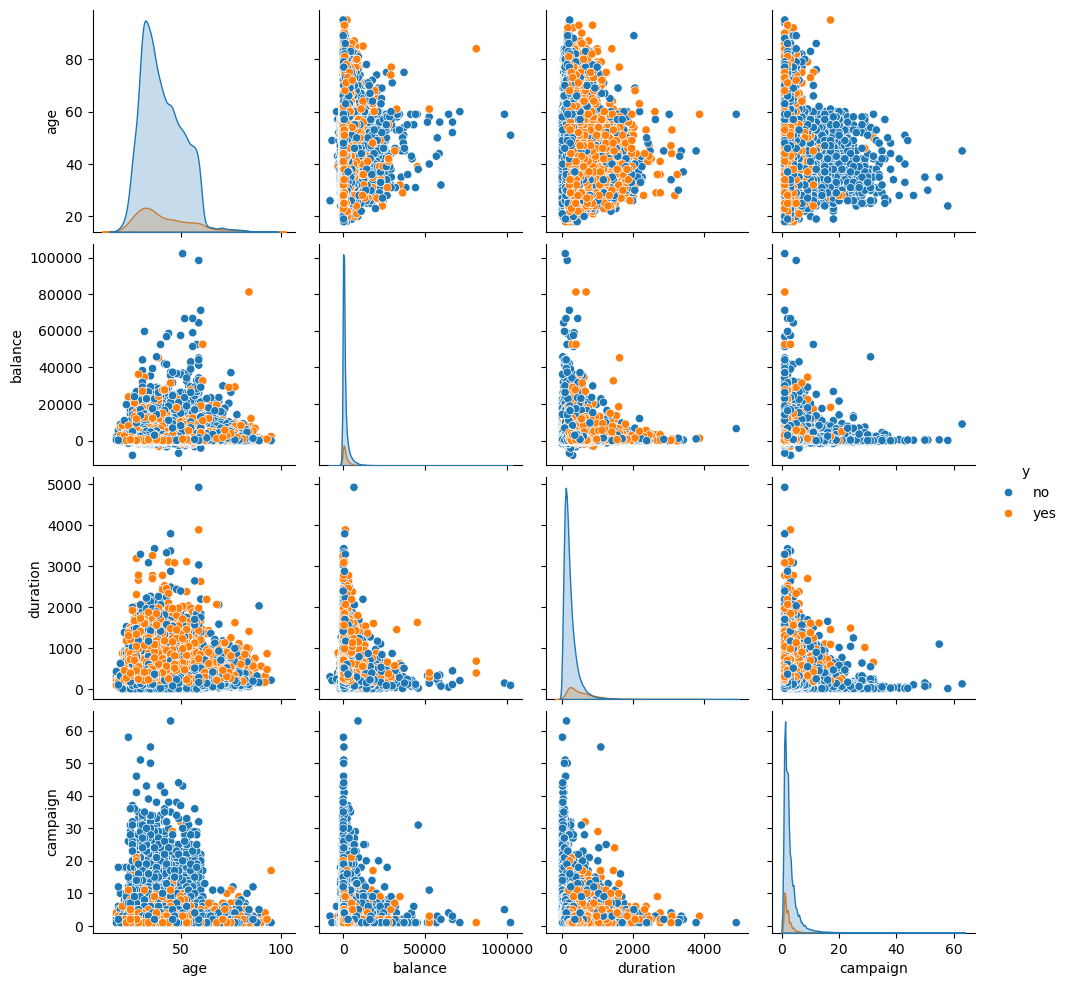

In [28]:
sns.pairplot(train[['age', 'balance', 'duration', 'campaign', 'y']],hue='y')
plt.show()

In [29]:
# Separate features and target

X = train.drop('y', axis=1)
y = train['y'].map({
    'no': 0,
    'yes': 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 16)
y shape: (45211,)


In [30]:
# Split data into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (36168, 16)
X_val: (9043, 16)
y_train: (36168,)
y_val: (9043,)


In [31]:
num_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

cat_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ]
)

In [33]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            'num',
            'passthrough',
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ]
)

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [35]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_train, y_train, X_val, y_val):

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    # Probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        val_prob = model.predict_proba(X_val)[:, 1]
    else:
        val_prob = None

    results = {
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Validation Accuracy': accuracy_score(y_val, val_pred),
        'Precision': precision_score(y_val, val_pred),
        'Recall': recall_score(y_val, val_pred),
        'F1 Score': f1_score(y_val, val_pred),
        'ROC-AUC': roc_auc_score(y_val, val_prob)
        if val_prob is not None else np.nan
    }

    print("Classification Report:")
    print(classification_report(y_val, val_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, val_pred))

    return results

In [37]:
logistic_results = evaluate_model(
    logistic_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

logistic_results

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043


Confusion Matrix:
[[6786 1199]
 [ 196  862]]


{'Train Accuracy': 0.8442545896925459,
 'Validation Accuracy': 0.8457370341700763,
 'Precision': 0.41824357108199905,
 'Recall': 0.8147448015122873,
 'F1 Score': 0.5527412632253927,
 'ROC-AUC': 0.9079218714674134}

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=20,
        class_weight='balanced',
        random_state=42
    ))
])

In [39]:
dt_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
dt_results = evaluate_model(
    dt_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

dt_results

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87      7985
           1       0.35      0.85      0.49      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.82      0.68      9043
weighted avg       0.90      0.80      0.83      9043


Confusion Matrix:
[[6300 1685]
 [ 157  901]]


{'Train Accuracy': 0.8031132492811325,
 'Validation Accuracy': 0.7963065354417782,
 'Precision': 0.34841453982985304,
 'Recall': 0.8516068052930057,
 'F1 Score': 0.49451152579582874,
 'ROC-AUC': 0.8853044993389071}

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [42]:
rf_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
rf_results = evaluate_model(
    rf_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

rf_results

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91      7985
           1       0.44      0.84      0.58      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.85      0.75      9043
weighted avg       0.91      0.86      0.87      9043


Confusion Matrix:
[[6862 1123]
 [ 172  886]]


{'Train Accuracy': 0.8765759787657598,
 'Validation Accuracy': 0.8567953112905009,
 'Precision': 0.4410154305624689,
 'Recall': 0.8374291115311909,
 'F1 Score': 0.5777632865992827,
 'ROC-AUC': 0.9230894884430046}

In [44]:
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ))
])

In [45]:
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    ))
])

In [46]:
svm_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
y_val_svm = svm_pipeline.predict(X_val)
y_train_svm = svm_pipeline.predict(X_train)

svm_results = {
    'Train Accuracy': accuracy_score(y_train, y_train_svm),
    'Validation Accuracy': accuracy_score(y_val, y_val_svm),
    'Precision': precision_score(y_val, y_val_svm),
    'Recall': recall_score(y_val, y_val_svm),
    'F1 Score': f1_score(y_val, y_val_svm)
}

svm_results

{'Train Accuracy': 0.8495631497456315,
 'Validation Accuracy': 0.8504920933318589,
 'Precision': 0.42657342657342656,
 'Recall': 0.8071833648393195,
 'F1 Score': 0.5581699346405229}

In [48]:
OneHotEncoder(handle_unknown='ignore', sparse_output=False)

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [49]:
preprocessor_nb = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            cat_cols
        )
    ]
)

In [50]:
from sklearn.naive_bayes import GaussianNB

nb_pipeline = Pipeline([
    ('preprocessor', preprocessor_nb),
    ('model', GaussianNB())
])

In [51]:
nb_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
nb_results = evaluate_model(
    nb_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

nb_results

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      7985
           1       0.41      0.52      0.46      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.71      0.69      9043
weighted avg       0.87      0.85      0.86      9043


Confusion Matrix:
[[7180  805]
 [ 508  550]]


{'Train Accuracy': 0.8519132935191329,
 'Validation Accuracy': 0.8548048214088245,
 'Precision': 0.4059040590405904,
 'Recall': 0.5198487712665406,
 'F1 Score': 0.45586406962287607,
 'ROC-AUC': 0.8100945416322902}

In [53]:
results = pd.DataFrame({
    'Logistic Regression': logistic_results,
    'Decision Tree': dt_results,
    'Random Forest': rf_results,
    'Naive Bayes': nb_results,
    'SVM': {
        'Train Accuracy': svm_results['Train Accuracy'],
        'Validation Accuracy': svm_results['Validation Accuracy'],
        'Precision': svm_results['Precision'],
        'Recall': svm_results['Recall'],
        'F1 Score': svm_results['F1 Score'],
        'ROC-AUC': np.nan
    }
}).T

results

,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.844255,0.845737,0.418244,0.814745,0.552741,0.907922
Decision Tree,0.803113,0.796307,0.348415,0.851607,0.494512,0.885304
Random Forest,0.876576,0.856795,0.441015,0.837429,0.577763,0.923089
Naive Bayes,0.851913,0.854805,0.405904,0.519849,0.455864,0.810095
SVM,0.849563,0.850492,0.426573,0.807183,0.558170,NaN


In [54]:
results.sort_values(
    by='F1 Score',
    ascending=False
)

,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.876576,0.856795,0.441015,0.837429,0.577763,0.923089
SVM,0.849563,0.850492,0.426573,0.807183,0.558170,NaN
Logistic Regression,0.844255,0.845737,0.418244,0.814745,0.552741,0.907922
Decision Tree,0.803113,0.796307,0.348415,0.851607,0.494512,0.885304
Naive Bayes,0.851913,0.854805,0.405904,0.519849,0.455864,0.810095


In [55]:
results['Overfitting Gap'] = (
    results['Train Accuracy']
    - results['Validation Accuracy']
)

results.sort_values(
    'Overfitting Gap',
    ascending=False
)

,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting Gap
Random Forest,0.876576,0.856795,0.441015,0.837429,0.577763,0.923089,0.019781
Decision Tree,0.803113,0.796307,0.348415,0.851607,0.494512,0.885304,0.006807
SVM,0.849563,0.850492,0.426573,0.807183,0.558170,NaN,-0.000929
Logistic Regression,0.844255,0.845737,0.418244,0.814745,0.552741,0.907922,-0.001482
Naive Bayes,0.851913,0.854805,0.405904,0.519849,0.455864,0.810095,-0.002892


In [56]:
# Create a copy of training features
df = train.drop('y', axis=1).copy()

print(df.shape)
df.head()

(45211, 16)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown


In [57]:
# 1. Whether customer was contacted previously
df['previously_contacted'] = (
    df['pdays'] != -1
).astype(int)


# 2. Whether customer had a previous campaign
df['has_previous_campaign'] = (
    df['previous'] > 0
).astype(int)


# 3. Total number of contacts
df['total_contacts'] = (
    df['campaign'] + df['previous']
)


# 4. Age group
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)


# 5. Log transformation of balance
df['balance_log'] = (
    np.sign(df['balance']) *
    np.log1p(np.abs(df['balance']))
)


# 6. Campaign intensity
df['campaign_intensity'] = (
    df['campaign'] /
    (df['previous'] + 1)
)

In [58]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,previously_contacted,has_previous_campaign,total_contacts,age_group,balance_log,campaign_intensity
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,1,-1,0,unknown,0,0,1,56-65,7.670429,1.0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,1,-1,0,unknown,0,0,1,36-45,3.401197,1.0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,1,-1,0,unknown,0,0,1,26-35,1.098612,1.0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,1,-1,0,unknown,0,0,1,46-55,7.317876,1.0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,1,-1,0,unknown,0,0,1,26-35,0.693147,1.0


In [59]:
new_features = [
    'previously_contacted',
    'has_previous_campaign',
    'total_contacts',
    'age_group',
    'balance_log',
    'campaign_intensity'
]

df[new_features].head()

,previously_contacted,has_previous_campaign,total_contacts,age_group,balance_log,campaign_intensity
0,0,0,1,56-65,7.670429,1.0
1,0,0,1,36-45,3.401197,1.0
2,0,0,1,26-35,1.098612,1.0
3,0,0,1,46-55,7.317876,1.0
4,0,0,1,26-35,0.693147,1.0


In [60]:
df[new_features].isnull().sum()

previously_contacted     0
has_previous_campaign    0
total_contacts           0
age_group                0
balance_log              0
campaign_intensity       0
dtype: int64

In [61]:
X_fe = df.copy()

y = train['y'].map({
    'no': 0,
    'yes': 1
})

print("X shape:", X_fe.shape)
print("y shape:", y.shape)

print(y.value_counts())

X shape: (45211, 22)
y shape: (45211,)
y
0    39922
1     5289
Name: count, dtype: int64


In [62]:
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(
    X_fe,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train_fe.shape)
print("X_val:", X_val_fe.shape)

X_train: (36168, 22)
X_val: (9043, 22)


In [63]:
num_cols_fe = X_fe.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols_fe = X_fe.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical columns:")
print(num_cols_fe)

print("\nCategorical columns:")
print(cat_cols_fe)

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'has_previous_campaign', 'total_contacts', 'balance_log', 'campaign_intensity']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_group']


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [65]:
preprocessor_scaled_fe = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols_fe
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols_fe
        )
    ]
)


In [66]:
preprocessor_tree_fe = ColumnTransformer(
    transformers=[
        (
            'num',
            'passthrough',
            num_cols_fe
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols_fe
        )
    ]
)

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_fe_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled_fe),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [68]:
logistic_fe_pipeline.fit(
    X_train_fe,
    y_train_fe
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
logistic_fe_results = evaluate_model(
    logistic_fe_pipeline,
    X_train_fe,
    y_train_fe,
    X_val_fe,
    y_val_fe
)

logistic_fe_results

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      7985
           1       0.43      0.82      0.56      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.84      0.74      9043
weighted avg       0.91      0.85      0.87      9043


Confusion Matrix:
[[6831 1154]
 [ 195  863]]


{'Train Accuracy': 0.8457752709577527,
 'Validation Accuracy': 0.8508238416454716,
 'Precision': 0.42786316311353495,
 'Recall': 0.8156899810964083,
 'F1 Score': 0.5613008130081301,
 'ROC-AUC': 0.9087192076826468}

In [70]:
comparison_lr = pd.DataFrame({
    'Original Features': logistic_results,
    'Feature Engineered': logistic_fe_results
})

comparison_lr

,Original Features,Feature Engineered
Train Accuracy,0.844255,0.845775
Validation Accuracy,0.845737,0.850824
Precision,0.418244,0.427863
Recall,0.814745,0.815690
F1 Score,0.552741,0.561301
ROC-AUC,0.907922,0.908719


In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_fe_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree_fe),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [72]:
rf_fe_pipeline.fit(
    X_train_fe,
    y_train_fe
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
rf_fe_results = evaluate_model(
    rf_fe_pipeline,
    X_train_fe,
    y_train_fe,
    X_val_fe,
    y_val_fe
)

rf_fe_results

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91      7985
           1       0.44      0.82      0.57      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.84      0.74      9043
weighted avg       0.91      0.86      0.87      9043


Confusion Matrix:
[[6885 1100]
 [ 188  870]]


{'Train Accuracy': 0.8800320725503207,
 'Validation Accuracy': 0.8575693906889307,
 'Precision': 0.4416243654822335,
 'Recall': 0.8223062381852552,
 'F1 Score': 0.5746367239101717,
 'ROC-AUC': 0.9187093475124082}

In [74]:
model_comparison = pd.DataFrame({
    'Logistic Regression': logistic_results,
    'Decision Tree': dt_results,
    'Random Forest': rf_results,
    'Naive Bayes': nb_results,
    'Logistic Regression + FE': logistic_fe_results,
    'Random Forest + FE': rf_fe_results
}).T

model_comparison

,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.844255,0.845737,0.418244,0.814745,0.552741,0.907922
Decision Tree,0.803113,0.796307,0.348415,0.851607,0.494512,0.885304
Random Forest,0.876576,0.856795,0.441015,0.837429,0.577763,0.923089
Naive Bayes,0.851913,0.854805,0.405904,0.519849,0.455864,0.810095
Logistic Regression + FE,0.845775,0.850824,0.427863,0.815690,0.561301,0.908719
Random Forest + FE,0.880032,0.857569,0.441624,0.822306,0.574637,0.918709


# DATA QUALITY INSIGHT

• Dataset contains no missing values.

• No duplicate rows were found.

• Data types were appropriate for numerical and categorical features.

• 'unknown' values were retained because they represent an actual category in the dataset.

• Therefore, no row deletion or imputation was required.

<Figure size 600x400 with 0 Axes>

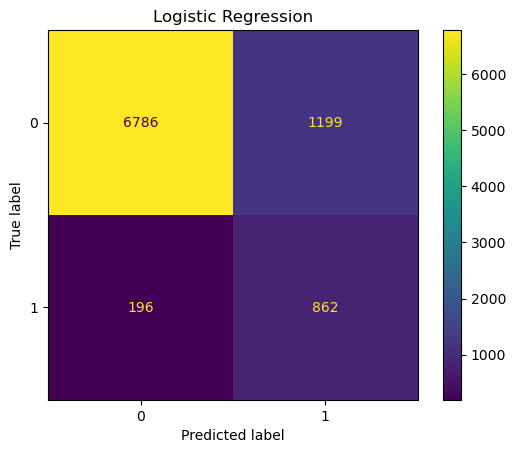

<Figure size 600x400 with 0 Axes>

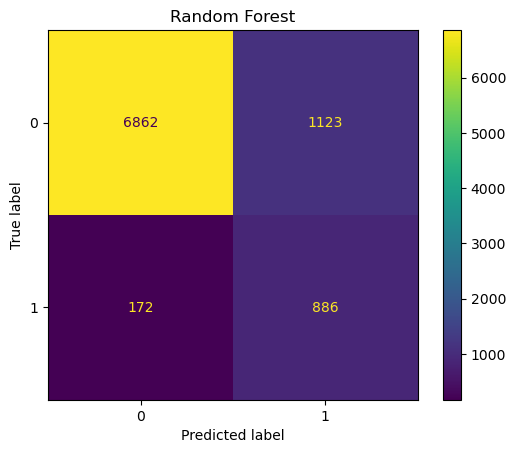

<Figure size 600x400 with 0 Axes>

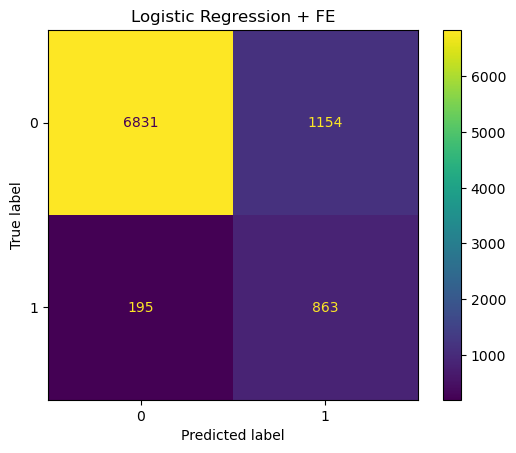

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    'Logistic Regression': logistic_pipeline,
    'Random Forest': rf_pipeline,
    'Logistic Regression + FE': logistic_fe_pipeline
}

for name, model in models.items():

    plt.figure(figsize=(6, 4))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_val if 'FE' not in name else X_val_fe,
        y_val if 'FE' not in name else y_val_fe
    )

    plt.title(name)
    plt.show()

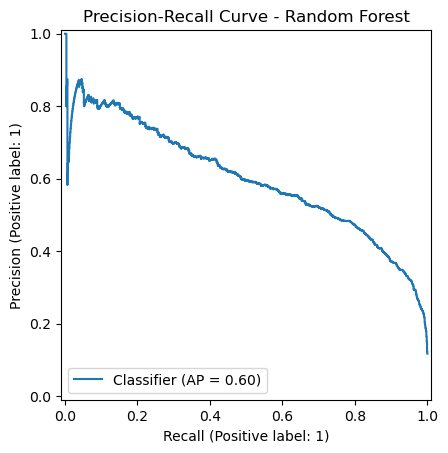

In [76]:
from sklearn.metrics import PrecisionRecallDisplay

y_val_prob_rf = rf_pipeline.predict_proba(X_val)[:, 1]

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_prob_rf
)

plt.title('Precision-Recall Curve - Random Forest')
plt.show()

<Figure size 800x600 with 0 Axes>

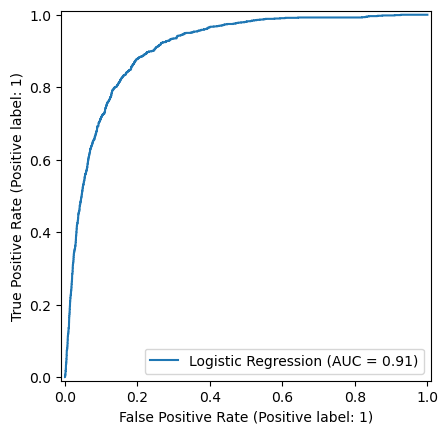

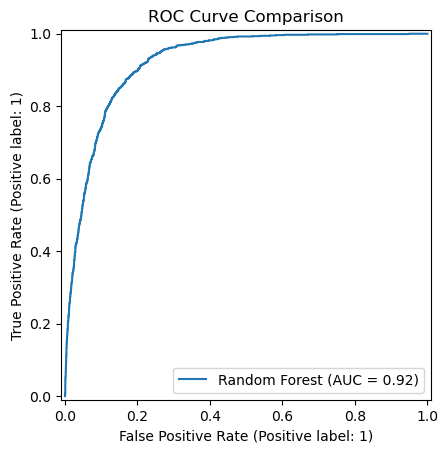

In [77]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    logistic_pipeline,
    X_val,
    y_val,
    name='Logistic Regression'
)

RocCurveDisplay.from_estimator(
    rf_pipeline,
    X_val,
    y_val,
    name='Random Forest'
)

plt.title('ROC Curve Comparison')
plt.show()

In [78]:
from sklearn.metrics import f1_score

def train_validation_analysis(model, X_train, y_train, X_val, y_val):

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_f1 = f1_score(y_train, train_pred)
    val_f1 = f1_score(y_val, val_pred)

    return {
        'Train F1': train_f1,
        'Validation F1': val_f1,
        'F1 Gap': train_f1 - val_f1
    }

In [79]:
overfitting_results = {}

overfitting_results['Logistic Regression'] = train_validation_analysis(
    logistic_pipeline,
    X_train, y_train,
    X_val, y_val
)

overfitting_results['Random Forest'] = train_validation_analysis(
    rf_pipeline,
    X_train, y_train,
    X_val, y_val
)

overfitting_results['Logistic Regression + FE'] = train_validation_analysis(
    logistic_fe_pipeline,
    X_train_fe, y_train_fe,
    X_val_fe, y_val_fe
)

pd.DataFrame(overfitting_results).T

,Train F1,Validation F1,F1 Gap
Logistic Regression,0.552759,0.552741,0.000018
Random Forest,0.637191,0.577763,0.059428
Logistic Regression + FE,0.557091,0.561301,-0.004210


In [80]:
feature_names = (
    rf_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    rf_pipeline
    .named_steps['model']
    .feature_importances_
)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
3,num__duration,0.436996
49,cat__poutcome_success,0.058267
34,cat__contact_unknown,0.042862
0,num__age,0.040493
5,num__pdays,0.035571
1,num__balance,0.035022
2,num__day,0.030396
29,cat__housing_yes,0.026563
28,cat__housing_no,0.026505
32,cat__contact_cellular,0.024472


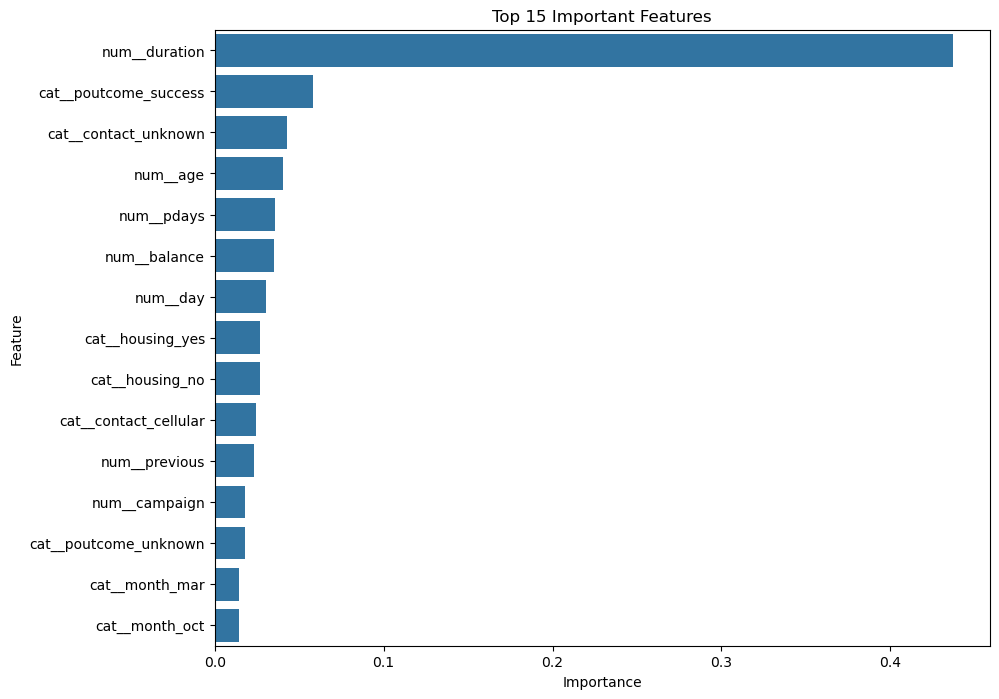

In [81]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Important Features')
plt.show()

In [82]:
X_no_duration = X.drop(columns=['duration'])

print(X_no_duration.shape)

(45211, 15)


In [83]:
num_cols_nd = X_no_duration.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols_nd = X_no_duration.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical columns:", num_cols_nd)
print("\nCategorical columns:", cat_cols_nd)

Numerical columns: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [84]:
X_train_nd, X_val_nd, y_train_nd, y_val_nd = train_test_split(
    X_no_duration,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [85]:
preprocessor_tree_nd = ColumnTransformer(
    transformers=[
        (
            'num',
            'passthrough',
            num_cols_nd
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols_nd
        )
    ]
)

In [86]:
rf_no_duration = Pipeline([
    ('preprocessor', preprocessor_tree_nd),

    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [87]:
rf_no_duration.fit(
    X_train_nd,
    y_train_nd
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
rf_no_duration_results = evaluate_model(
    rf_no_duration,
    X_train_nd,
    y_train_nd,
    X_val_nd,
    y_val_nd
)

rf_no_duration_results

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.64      0.21      0.32      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043


Confusion Matrix:
[[7857  128]
 [ 833  225]]


{'Train Accuracy': 1.0,
 'Validation Accuracy': 0.8937299568727193,
 'Precision': 0.6373937677053825,
 'Recall': 0.21266540642722118,
 'F1 Score': 0.3189227498228207,
 'ROC-AUC': 0.79228509741209}

In [89]:
duration_comparison = pd.DataFrame({
    'Random Forest With Duration': rf_results,
    'Random Forest Without Duration': rf_no_duration_results
}).T

duration_comparison

,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest With Duration,0.876576,0.856795,0.441015,0.837429,0.577763,0.923089
Random Forest Without Duration,1.000000,0.893730,0.637394,0.212665,0.318923,0.792285


In [90]:
rf_no_duration = Pipeline([
    ('preprocessor', preprocessor_tree_nd),
    
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [91]:
rf_no_duration.fit(
    X_train_nd,
    y_train_nd
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [92]:
rf_no_duration_results = evaluate_model(
    rf_no_duration,
    X_train_nd,
    y_train_nd,
    X_val_nd,
    y_val_nd
)

rf_no_duration_results

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      7985
           1       0.37      0.59      0.45      1058

    accuracy                           0.83      9043
   macro avg       0.65      0.73      0.68      9043
weighted avg       0.87      0.83      0.85      9043


Confusion Matrix:
[[6920 1065]
 [ 439  619]]


{'Train Accuracy': 0.8540145985401459,
 'Validation Accuracy': 0.8336835121088134,
 'Precision': 0.3675771971496437,
 'Recall': 0.5850661625708885,
 'F1 Score': 0.45149525893508385,
 'ROC-AUC': 0.7985709263470141}

In [93]:
duration_comparison = pd.DataFrame({
    'Random Forest With Duration': rf_results,
    'Random Forest Without Duration': rf_no_duration_results
}).T

duration_comparison

,Train Accuracy,Validation Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest With Duration,0.876576,0.856795,0.441015,0.837429,0.577763,0.923089
Random Forest Without Duration,0.854015,0.833684,0.367577,0.585066,0.451495,0.798571


# ✨ FINAL INSIGHTS & CONCLUSIONS — NOTEBOOK 1

## 1. Problem Understanding

This project is a binary classification problem where the objective is to
predict whether a bank customer will subscribe to a term deposit.

Target variable:
- `y = yes` → Customer subscribed
- `y = no` → Customer did not subscribe

The business objective is to improve telemarketing effectiveness by identifying
customers who are more likely to subscribe.

---

## 2. Data & Preprocessing

The dataset contains numerical and categorical variables related to:

- Customer demographics
- Financial status
- Contact information
- Current campaign activity
- Previous campaign history

Categorical variables were converted into numerical representations using
One-Hot Encoding, while numerical variables were retained appropriately for
the tree-based models.

The preprocessing was implemented using a pipeline/ColumnTransformer approach
during model development to maintain a consistent transformation process.

---

## 3. Class Imbalance

The target variable is imbalanced, with non-subscribers representing the
majority class.

Therefore, accuracy alone is not sufficient to judge model performance.

The following metrics were considered:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Accuracy
- Confusion Matrix

Recall and F1 Score were particularly important because correctly identifying
potential subscribers is an important business objective.

---

## 4. Model Comparison

Multiple classification models were evaluated, including:

- Logistic Regression
- Decision Tree
- Random Forest
- Naive Bayes

Random Forest produced the strongest overall performance among the tested
baseline models.

The Random Forest model achieved:

- Validation Accuracy: 85.68%
- Precision: 44.10%
- Recall: 83.74%
- F1 Score: 57.78%
- ROC-AUC: 92.31%

The high ROC-AUC indicates strong ability to distinguish between subscribers
and non-subscribers.

---

## 5. Feature Engineering Experiment

Additional domain-based features were created and evaluated.

Feature engineering produced a small improvement for Logistic Regression but
did not improve Random Forest performance.

Random Forest comparison:

Original Random Forest:
- F1 Score: 0.5778
- ROC-AUC: 0.9231

Random Forest + Feature Engineering:
- F1 Score: 0.5746
- ROC-AUC: 0.9187

Therefore, the additional engineered features were not retained automatically
for the final Random Forest model.

This demonstrates that feature engineering should be evaluated empirically
rather than assuming that additional features will always improve a model.

---

## 6. Feature Importance

Random Forest feature importance showed that `duration` was by far the most
important feature.

Other important variables included:

- Previous campaign outcome
- Contact type
- Age
- Pdays
- Balance
- Day
- Housing status
- Previous contacts
- Campaign contacts
- Month

These variables provide useful information about customer response behaviour
and campaign history.

---

## 7. Duration Experiment

A separate experiment was conducted by removing `duration`.

### Random Forest With Duration

- Validation Accuracy: 85.68%
- Precision: 44.10%
- Recall: 83.74%
- F1 Score: 57.78%
- ROC-AUC: 92.31%

### Random Forest Without Duration

- Validation Accuracy: 83.37%
- Precision: 36.76%
- Recall: 58.51%
- F1 Score: 45.15%
- ROC-AUC: 79.86%

Removing `duration` resulted in a significant decrease in Recall, F1 Score and
ROC-AUC.

This confirms that `duration` contains substantial predictive information.

---

## 8. Important Business Insight — Feature Availability

Although `duration` provides a very strong predictive signal, it represents the
duration of the current call.

Therefore, it is not available before the customer is contacted.

This creates an important distinction between model performance and business
validity.

### Model including duration

Provides stronger predictive performance but is appropriate when call-duration
information is already available.

### Model excluding duration

Provides lower predictive performance but is more appropriate for a genuine
pre-call customer-targeting use case.

Therefore, the final production model should be selected based not only on
performance but also on whether the required features are available at the
time the prediction is made.

---

## 9. Key Machine Learning Learnings

The experiments provided the following conclusions:

1. Accuracy can be misleading when the target classes are imbalanced.
2. Precision, Recall and F1 Score provide better information about minority-class
   performance.
3. ROC-AUC is useful for evaluating the model's ability to distinguish between
   the two classes.
4. Random Forest performed better than the other baseline models tested.
5. Feature engineering does not necessarily improve tree-based models.
6. Feature importance helps identify influential variables but does not imply
   causation.
7. A highly predictive feature may still be unsuitable for deployment if it is
   unavailable at prediction time.
8. Model selection should consider both technical performance and business
   requirements.
9. The classification threshold can affect the trade-off between Precision and
   Recall and should therefore be considered during final optimization.

---

## 10. Final Decision Before Notebook 2

The exploratory analysis identifies Random Forest as the strongest baseline
model.

Two model configurations will be considered in the final development stage:

### A. Performance-oriented model
Random Forest including `duration`.

### B. Business-oriented pre-call model
Random Forest excluding `duration`.

The final model will be selected after:

- Hyperparameter tuning
- Cross-validation
- Threshold analysis
- Validation performance comparison
- Business-use-case evaluation

The untouched test dataset will be used only for the final unbiased evaluation.

---

# 🚀 Transition to Notebook 2

Notebook 1 is now complete.

Notebook 2 will focus exclusively on building the final production-oriented
machine learning solution.

The workflow will be:

Data Loading
↓
Business Feature Decision
↓
Train/Validation Split
↓
Preprocessing Pipeline
↓
Baseline Random Forest
↓
Hyperparameter Tuning
↓
Cross-Validation
↓
Threshold Optimization
↓
Final Model Selection
↓
Final Evaluation on Unseen Test Data
↓
Model Serialization
↓
Deployment-Ready Pipeline

The objective of Notebook 2 is not to explore randomly, but to build a clean,
reproducible and deployment-ready solution.